# Project Name: Premium prediction for Health insurance

# Step-1: Data Loading + EDA + Data Cleaning

In [2]:
# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("premium_rest.xlsx")
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,Female,Northwest,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,26,High blood pressure,Gold,26370
29900,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,Gold,29496
29901,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,Bronze,10957
29902,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076


In [4]:
df['Genetical_Risk'] = 0
df

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,Female,Northwest,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,26,High blood pressure,Gold,26370,0
29900,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,Gold,29496,0
29901,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,Bronze,10957,0
29902,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,Gold,27076,0


# EDA + Data cleaning

In [5]:
df.shape

(29904, 14)

In [6]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [7]:
df.columns = df.columns.str.lower()

In [8]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number of dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

In [9]:
df.columns = df.columns.str.replace(" ", "_")

In [10]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

# Handling of Null values

In [11]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [12]:
df.dropna(inplace = True)

In [13]:
df.isnull().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

# Handling Duplicate values

In [14]:
print(df.duplicated().sum())

0


In [15]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29886.000000,29886.000000,29886.000000,29886.000000,29886.0
mean,43.396105,2.379910,23.364184,20892.303821,0.0
std,13.412657,1.431201,24.740339,6936.813440,0.0
min,26.000000,-3.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15697.250000,0.0
50%,42.000000,3.000000,17.000000,20489.000000,0.0
75%,52.000000,3.000000,32.000000,26360.000000,0.0
max,356.000000,5.000000,930.000000,43471.000000,0.0


## Resolve Negative value in number of dependent column

In [16]:
df[df.number_of_dependants < 0]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1805,34,Female,Southeast,Married,-1,Underweight,Regular,Self-Employed,25L - 40L,35,High blood pressure & Heart disease,Silver,22995,0
2273,41,Male,Southwest,Married,-1,Obesity,Regular,Salaried,10L - 25L,21,Diabetes,Silver,22766,0
3513,56,Male,Southwest,Married,-3,Normal,Occasional,Salaried,10L - 25L,16,Thyroid,Bronze,11979,0
3904,26,Male,Southeast,Married,-1,Obesity,Occasional,Freelancer,25L - 40L,27,No Disease,Silver,18269,0
4900,37,Male,Northwest,Married,-1,Overweight,Regular,Self-Employed,<10L,8,Diabetes,Bronze,13664,0
5917,42,Female,Southeast,Unmarried,-3,Overweight,Regular,Self-Employed,<10L,8,Diabetes & Heart disease,Bronze,17779,0
7095,50,Female,Northwest,Married,-3,Normal,Occasional,Salaried,<10L,4,Diabetes & High blood pressure,Silver,21957,0
7222,47,Male,Northwest,Unmarried,-3,Overweight,Occasional,Self-Employed,10L - 25L,19,No Disease,Gold,27457,0
7551,39,Male,Southwest,Unmarried,-1,Overweight,Occasional,Self-Employed,25L - 40L,40,High blood pressure,Silver,18406,0
9047,47,Male,Northwest,Married,-1,Overweight,Occasional,Self-Employed,25L - 40L,27,High blood pressure,Gold,29812,0


In [17]:
df[df.number_of_dependants < 0]['number_of_dependants'].unique()

array([-1, -3])

In [18]:
# By mistage customer write +3 to -3 and +1 to -1
df.number_of_dependants = df.number_of_dependants.abs()

In [19]:
df.number_of_dependants.unique()

array([0, 2, 3, 4, 1, 5])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29886 entries, 0 to 29903
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    29886 non-null  int64 
 1   gender                 29886 non-null  object
 2   region                 29886 non-null  object
 3   marital_status         29886 non-null  object
 4   number_of_dependants   29886 non-null  int64 
 5   bmi_category           29886 non-null  object
 6   smoking_status         29886 non-null  object
 7   employment_status      29886 non-null  object
 8   income_level           29886 non-null  object
 9   income_lakhs           29886 non-null  int64 
 10  medical_history        29886 non-null  object
 11  insurance_plan         29886 non-null  object
 12  annual_premium_amount  29886 non-null  int64 
 13  genetical_risk         29886 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 3.4+ MB


# Handling of Outliers

In [21]:
numeric_columns = df.select_dtypes(include = "int64").columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

## Box plot for Outliers

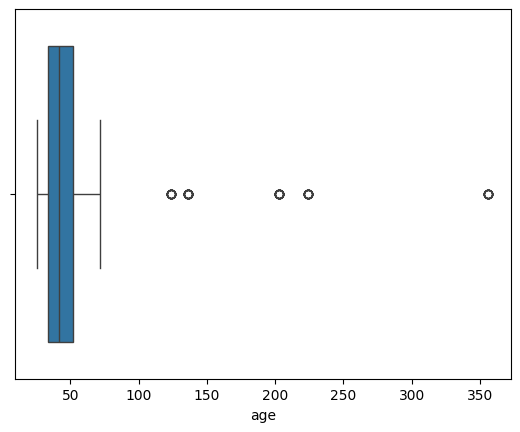

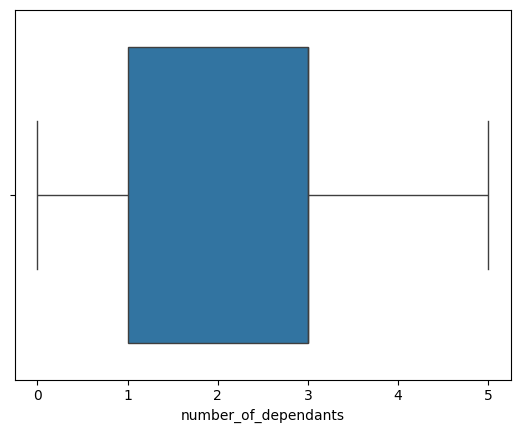

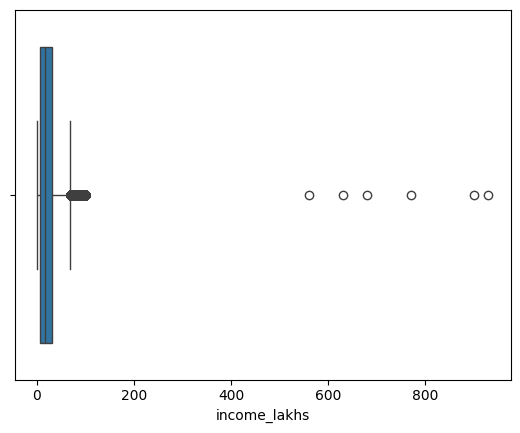

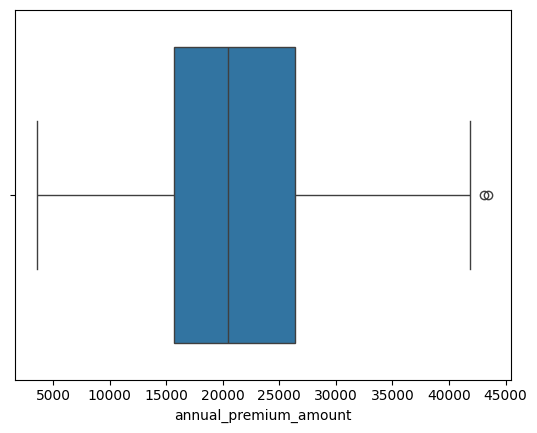

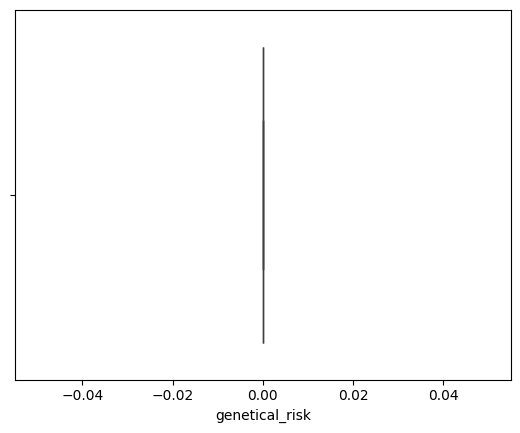

In [22]:
for col in numeric_columns:
    sns.boxplot(x = df[col])
    plt.show()

### Handling of outlier in age column

In [23]:
Q1 = np.percentile(df.age, 25)
Q3 = np.percentile(df.age, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

34.0
52.0
79.0


In [24]:
df[df.age > 100].count()

age                      58
gender                   58
region                   58
marital_status           58
number_of_dependants     58
bmi_category             58
smoking_status           58
employment_status        58
income_level             58
income_lakhs             58
medical_history          58
insurance_plan           58
annual_premium_amount    58
genetical_risk           58
dtype: int64

In [25]:
df[df.age > 100]['age'].unique()

array([224, 124, 136, 203, 356])

In [26]:
df[df.age > 100]['age'].value_counts()

age
136    15
203    13
124    11
224    10
356     9
Name: count, dtype: int64

In [27]:
median_age = df.age.median()
print(median_age)

42.0


In [28]:
df.loc[df.age > 100, 'age'] = median_age

In [29]:
df[df.age > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

### Handling outliers in income_lakhs column

In [30]:
Q1 = np.percentile(df.income_lakhs, 25)
Q3 = np.percentile(df.income_lakhs, 75)
print(Q1)
print(Q3)
IQR = Q3 - Q1
UB = Q3 + 1.5 * IQR
print(UB)

7.0
32.0
69.5


In [31]:
df[df.income_lakhs > 100].count()

age                      6
gender                   6
region                   6
marital_status           6
number_of_dependants     6
bmi_category             6
smoking_status           6
employment_status        6
income_level             6
income_lakhs             6
medical_history          6
insurance_plan           6
annual_premium_amount    6
genetical_risk           6
dtype: int64

In [32]:
df.shape

(29886, 14)

In [33]:
df[df.income_lakhs > 100]

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
1598,51,Male,Northwest,Married,4,Obesity,No Smoking,Self-Employed,> 40L,560,High blood pressure,Gold,30692,0
4657,35,Female,Northeast,Unmarried,0,Overweight,No Smoking,Salaried,> 40L,630,Diabetes,Gold,24010,0
5399,43,Male,Southeast,Married,3,Obesity,Regular,Salaried,> 40L,900,Diabetes & Thyroid,Gold,30848,0
6149,37,Female,Southeast,Married,3,Normal,No Smoking,Freelancer,> 40L,930,Diabetes,Silver,15945,0
21176,59,Male,Northwest,Married,2,Obesity,Occasional,Self-Employed,> 40L,770,Thyroid,Gold,31115,0
24489,48,Male,Northeast,Married,4,Obesity,No Smoking,Salaried,> 40L,680,No Disease,Gold,28926,0


In [34]:
# deleted the Outliers
df = df[df.income_lakhs <= 100]

In [35]:
df[df.income_lakhs > 100].count()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [36]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,29880.000000,29880.000000,29880.000000,29880.000000,29880.0
mean,43.092771,2.385877,23.219277,20891.092905,0.0
std,11.031813,1.421141,22.448006,6936.548756,0.0
min,26.000000,0.000000,1.000000,3625.000000,0.0
25%,34.000000,1.000000,7.000000,15695.750000,0.0
50%,42.000000,3.000000,17.000000,20488.000000,0.0
75%,52.000000,3.000000,32.000000,26359.250000,0.0
max,72.000000,5.000000,100.000000,43471.000000,0.0


## EDA & Data Cleaning on Categorical variables

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29880 entries, 0 to 29903
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    29880 non-null  int64 
 1   gender                 29880 non-null  object
 2   region                 29880 non-null  object
 3   marital_status         29880 non-null  object
 4   number_of_dependants   29880 non-null  int64 
 5   bmi_category           29880 non-null  object
 6   smoking_status         29880 non-null  object
 7   employment_status      29880 non-null  object
 8   income_level           29880 non-null  object
 9   income_lakhs           29880 non-null  int64 
 10  medical_history        29880 non-null  object
 11  insurance_plan         29880 non-null  object
 12  annual_premium_amount  29880 non-null  int64 
 13  genetical_risk         29880 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 3.4+ MB


In [38]:
categorical_columns = df.select_dtypes(include = "object").columns
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [39]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


In [40]:
df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_6148\1074089374.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.smoking_status = df.smoking_status.replace({'Smoking=0' : 'No Smoking', 'Does Not Smoke' : 'No Smoking', 'Not Smoking' : 'No Smoking'})


In [41]:
df.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

# Step-2 : Feature Engineering

### convert the Categorical variable into Numerical variables

In [42]:
categorical_columns

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

### Ordinal Encoding: Rank or Order 'income_level', 'insurance_plan'

In [43]:
from sklearn.preprocessing import OrdinalEncoder

In [44]:
encoder = OrdinalEncoder(categories = [['Bronze', 'Silver', 'Gold']])
df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_6148\1274939803.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = encoder.fit_transform(df[['insurance_plan']])


In [45]:
df.insurance_plan = df.insurance_plan.astype('int64')

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_6148\355962698.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.insurance_plan = df.insurance_plan.astype('int64')


In [46]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,0,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,0,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,1,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,2,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,0,15610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,Female,Northwest,Married,3,Normal,No Smoking,Self-Employed,25L - 40L,26,High blood pressure,2,26370,0
29900,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,10L - 25L,16,Diabetes & Thyroid,2,29496,0
29901,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,<10L,4,No Disease,0,10957,0
29902,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,> 40L,82,Thyroid,2,27076,0


In [47]:
encoder = OrdinalEncoder(categories = [['<10L', '10L - 25L', '25L - 40L', '> 40L']])
df.income_level = encoder.fit_transform(df[['income_level']])

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_6148\2938848440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.income_level = encoder.fit_transform(df[['income_level']])


In [48]:
df

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,0.0,6,Diabetes,0,9053,0
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,0.0,6,Diabetes,0,16339,0
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,1.0,20,High blood pressure,1,18164,0
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,3.0,77,No Disease,2,20303,0
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,1.0,14,Diabetes,0,15610,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,Female,Northwest,Married,3,Normal,No Smoking,Self-Employed,2.0,26,High blood pressure,2,26370,0
29900,40,Female,Southeast,Unmarried,0,Overweight,Regular,Salaried,1.0,16,Diabetes & Thyroid,2,29496,0
29901,37,Female,Northwest,Unmarried,0,Obesity,No Smoking,Salaried,0.0,4,No Disease,0,10957,0
29902,47,Female,Southeast,Married,2,Normal,No Smoking,Salaried,3.0,82,Thyroid,2,27076,0


# Use Label encoding to convert categorical column to numerical number

In [49]:
for col in categorical_columns:
    print(col, ":", df[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : [0. 1. 3. 2.]
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : [0 1 2]


In [50]:
# Use label encoding when their is NO RANKING between the classes in the data

from sklearn.preprocessing import LabelEncoder

In [51]:
encoder = LabelEncoder()
df.region = encoder.fit_transform(df.region)

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_6148\166564218.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.region = encoder.fit_transform(df.region)


In [52]:
encoder = LabelEncoder()
df.bmi_category = encoder.fit_transform(df.bmi_category)

C:\Users\DELL ADMIN\AppData\Local\Temp\ipykernel_6148\744827222.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.bmi_category = encoder.fit_transform(df.bmi_category)


In [53]:
# One hot encoding: Convert categorical data to numerical
# When number of sub-categories are less
df = pd.get_dummies(df, columns = ['gender', 'marital_status', 'smoking_status', 'employment_status'], drop_first = True, dtype = int)

In [54]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,1,0,0,0.0,6,Diabetes,0,9053,0,1,1,0,0,1,0
1,29,2,2,1,0.0,6,Diabetes,0,16339,0,0,0,0,1,1,0
2,49,0,2,0,1.0,20,High blood pressure,1,18164,0,0,0,0,0,0,1
3,30,2,3,0,3.0,77,No Disease,2,20303,0,0,0,0,0,1,0
4,56,0,3,1,1.0,14,Diabetes,0,15610,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,1,3,0,2.0,26,High blood pressure,2,26370,0,0,0,0,0,0,1
29900,40,2,0,2,1.0,16,Diabetes & Thyroid,2,29496,0,0,1,0,1,1,0
29901,37,1,0,1,0.0,4,No Disease,0,10957,0,0,1,0,0,1,0
29902,47,2,2,0,3.0,82,Thyroid,2,27076,0,0,0,0,0,1,0


# Covert categorical column to numerical : Manually

In [55]:
df.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

In [56]:
risk_score = {
                'Diabetes' : 6,
                'High blood pressure' : 6,
                'Heart disease' : 8,
                'Thyroid' : 5,
                'No Disease' : 0,
                'Diabetes & High blood pressure' : 12,
                'High blood pressure & Heart disease' : 14,
                'Diabetes & Thyroid' : 11,
                'Diabetes & Heart disease' : 14
}
df.medical_history = df.medical_history.map(risk_score)

In [57]:
df

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,1,0,0,0.0,6,6,0,9053,0,1,1,0,0,1,0
1,29,2,2,1,0.0,6,6,0,16339,0,0,0,0,1,1,0
2,49,0,2,0,1.0,20,6,1,18164,0,0,0,0,0,0,1
3,30,2,3,0,3.0,77,0,2,20303,0,0,0,0,0,1,0
4,56,0,3,1,1.0,14,6,0,15610,0,1,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,1,3,0,2.0,26,6,2,26370,0,0,0,0,0,0,1
29900,40,2,0,2,1.0,16,11,2,29496,0,0,1,0,1,1,0
29901,37,1,0,1,0.0,4,0,0,10957,0,0,1,0,0,1,0
29902,47,2,2,0,3.0,82,5,2,27076,0,0,0,0,0,1,0


# Feature Scaling

In [58]:
from sklearn.preprocessing import MinMaxScaler

In [59]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk', 'gender_Male',
       'marital_status_Unmarried', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

In [60]:
cols_to_scale = ['age', 'region', 'number_of_dependants', 'bmi_category', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
      'gender_Male', 'marital_status_Unmarried',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed']

In [61]:
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Remove the features which are related to each other

# Correaltion matrix + Heatmap

In [62]:
cm = df.corr()

<Axes: >

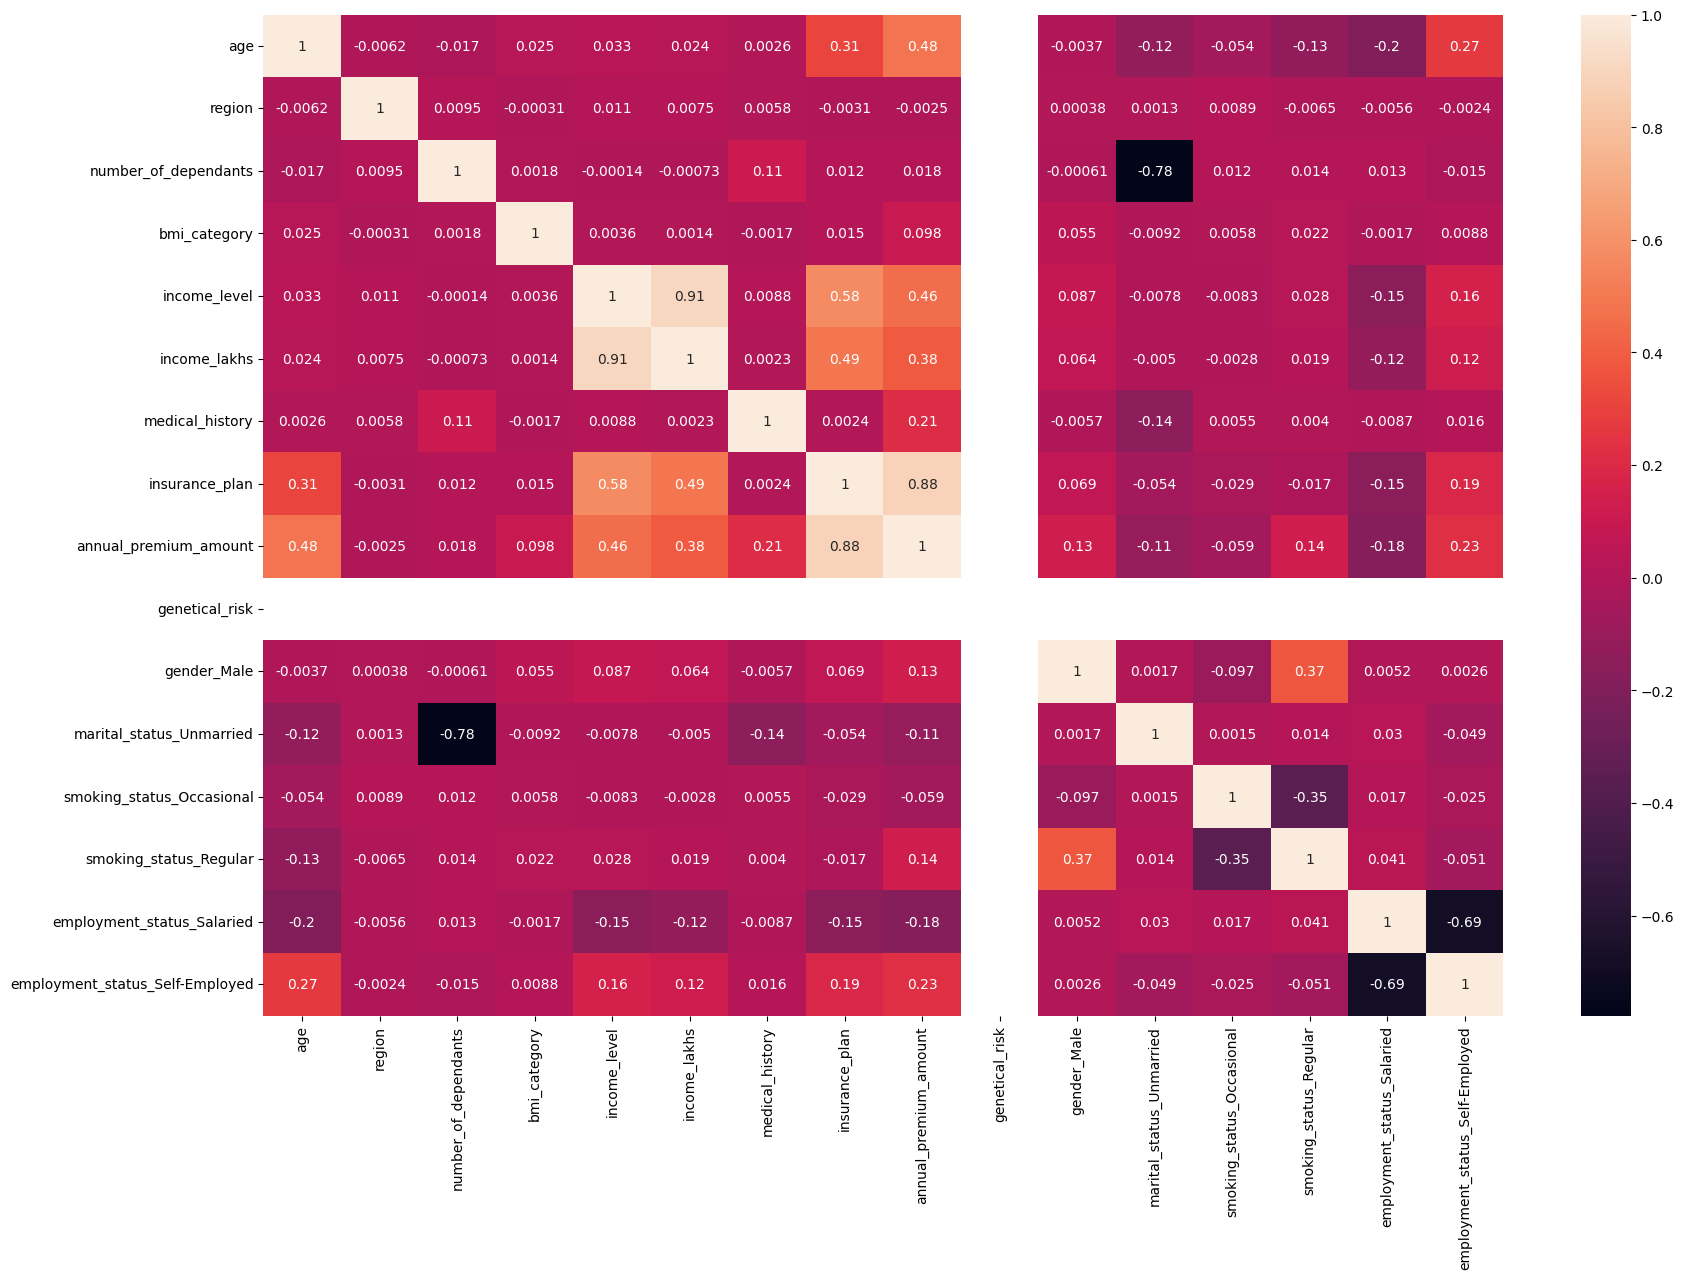

In [63]:
plt.figure(figsize = (20, 13))
sns.heatmap(cm, annot = True)

# Delete the highly correlated features : more than 80% related
 # number_of_dependents = marital_status_unmarried
# income_level = income_lakhs

# Don't delete the features which are related to target variable

In [64]:
df.drop(['marital_status_Unmarried', 'income_level'], axis = 1, inplace = True)

In [65]:
df.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'annual_premium_amount',
       'genetical_risk', 'gender_Male', 'smoking_status_Occasional',
       'smoking_status_Regular', 'employment_status_Salaried',
       'employment_status_Self-Employed'],
      dtype='object')

# Step-4 : Model training & downloading/saving trained model

In [66]:
# Linear regresssion
# Xgboost

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
df

,age,region,number_of_dependants,bmi_category,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.333333,0.0,0.000000,0.050505,0.428571,0.0,9053,0,1.0,0.0,0.0,1.0,0.0
1,0.065217,0.666667,0.4,0.333333,0.050505,0.428571,0.0,16339,0,0.0,0.0,1.0,1.0,0.0
2,0.500000,0.000000,0.4,0.000000,0.191919,0.428571,0.5,18164,0,0.0,0.0,0.0,0.0,1.0
3,0.086957,0.666667,0.6,0.000000,0.767677,0.000000,1.0,20303,0,0.0,0.0,0.0,1.0,0.0
4,0.652174,0.000000,0.6,0.333333,0.131313,0.428571,0.0,15610,0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,0.739130,0.333333,0.6,0.000000,0.252525,0.428571,1.0,26370,0,0.0,0.0,0.0,0.0,1.0
29900,0.304348,0.666667,0.0,0.666667,0.151515,0.785714,1.0,29496,0,0.0,0.0,1.0,1.0,0.0
29901,0.239130,0.333333,0.0,0.333333,0.030303,0.000000,0.0,10957,0,0.0,0.0,0.0,1.0,0.0
29902,0.456522,0.666667,0.4,0.000000,0.818182,0.357143,1.0,27076,0,0.0,0.0,0.0,1.0,0.0


In [68]:
x = df.drop("annual_premium_amount", axis = 1)
y = df.annual_premium_amount
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2,random_state=42)

In [69]:
Linear_obj=LinearRegression()
Linear_obj.fit(x_train,y_train)

LinearRegression()

In [70]:
lr_score=Linear_obj.score(x_test,y_test)
print(lr_score)

0.9132548081401505


In [71]:
import xgboost as xgb

pip install --upgrade xgboost
# Your scikit-learn version is newer


# Your scikit-learn version is newer
👉 Your xgboost version is older

New versions of scikit-learn (>=1.6) expect models to implement __sklearn_tags__(),
but older xgboost versions don’t support it.

So when RandomizedSearchCV checks whether the model is a classifier/regressor, it crashes.

In [72]:
XGB_obj=xgb.XGBRegressor()

In [73]:
#hyper parameter tuning
from sklearn.model_selection import RandomizedSearchCV
param_gird={
    'n_estimators':[20,30,40,50],
    'learning_rate':[0.001,0.01,0.5],
    'max_depth':[3,4,5,6]
}
random_search=RandomizedSearchCV(XGB_obj,param_gird,cv=3)
random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   param_distributions={'learning_rate': [0.001, 0.01, 0.5],
                                        'max_depth': [3, 4, 5, 6],
                                        'n_estimators': [20, 30, 40, 50]})

In [74]:
random_search.best_score_

np.float64(0.9971059958140055)

In [75]:
# Target1: performnace must be greater than 97%
# Target 2:Difference between actual premium and predicated premium<10%

In [76]:
y_pred=random_search.predict(x_test)
y_pred

array([26631.186, 15631.948, 11524.565, ..., 22862.646,  6642.134,
       15543.721], dtype=float32)

In [77]:
residuals=y_pred-y_test
residuals_pct=(residuals/y_test)*100
print(residuals_pct)

5945     -1.223302
18194    -0.281014
12985    -1.448902
29274     0.134973
15689    -0.105815
           ...    
22841    -2.019669
10574     1.412067
8246     -1.560187
2556     26.420514
11829     1.090795
Name: annual_premium_amount, Length: 5976, dtype: float64


In [78]:
result_df=pd.DataFrame({
    'Actaul':y_test,
    'Predicted':y_pred,
    'Diff':residuals,
    'Diff_pct':residuals_pct
})

In [79]:
result_df.head(10)

,Actaul,Predicted,Diff,Diff_pct
5945,26961,26631.185547,-329.814453,-1.223302
18194,15676,15631.948242,-44.051758,-0.281014
12985,11694,11524.565430,-169.434570,-1.448902
29274,19596,19622.449219,26.449219,0.134973
15689,31565,31531.599609,-33.400391,-0.105815
17915,11681,12183.341797,502.341797,4.300503
8581,18699,18574.009766,-124.990234,-0.668433
6752,25712,25625.316406,-86.683594,-0.337133
17749,25031,25051.767578,20.767578,0.082967
28592,15169,15488.577148,319.577148,2.106778


<Axes: xlabel='Diff_pct', ylabel='Count'>

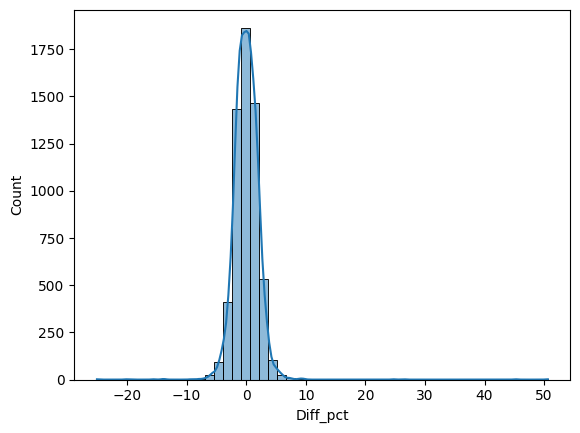

In [80]:
# plotting the chart 
# histplot to know the distribution OF difference percenatage b/w actual and predicated
import seaborn as sns
sns.histplot(result_df['Diff_pct'],bins=50,kde=True)

In [81]:
# extreme Data
extreme_result_df=result_df[np.abs(result_df.Diff_pct>10)]
extreme_result_df

,Actaul,Predicted,Diff,Diff_pct
23518,4568,6635.135742,2067.135742,45.252534
19495,9092,13695.055664,4603.055664,50.627537
803,5311,6627.477539,1316.477539,24.787753
2556,5254,6642.133789,1388.133789,26.420514


In [82]:
extreme_result_df.shape

(4, 4)

In [83]:
# calculate percenatge
x_test.shape

(5976, 13)

In [84]:
(1523/9994)*100

15.239143486091656

### 5% values with more than 10% difference is allowed
### but we are getting 15% records having difference more than 10%

In [85]:
# finding complete record where extreme values exists
extreme_error_df=x_test.loc[extreme_result_df.index]
extreme_error_df.head()

,age,region,number_of_dependants,bmi_category,income_lakhs,medical_history,insurance_plan,genetical_risk,gender_Male,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
23518,0.347826,0.666667,0.2,0.0,0.070707,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0
19495,0.347826,1.000000,0.4,1.0,0.030303,0.0,0.5,0,1.0,0.0,0.0,0.0,0.0
803,0.347826,0.333333,0.0,0.0,0.020202,0.0,0.0,0,0.0,0.0,0.0,1.0,0.0
2556,0.347826,0.666667,0.0,0.0,0.171717,0.0,0.0,0,1.0,0.0,0.0,0.0,0.0


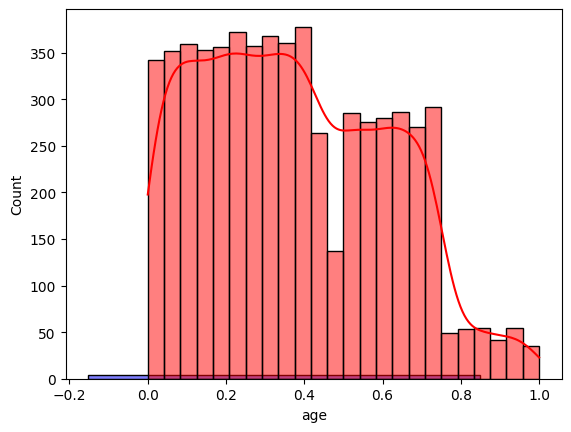

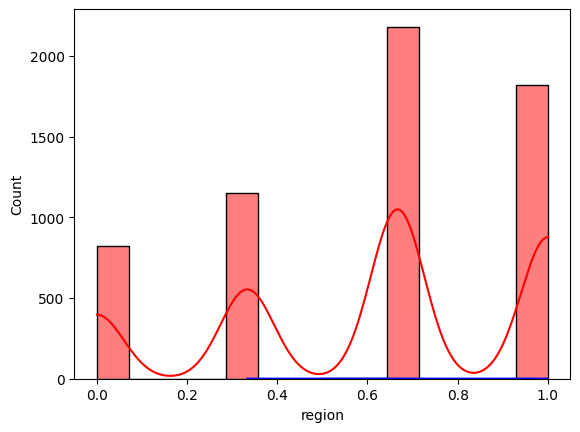

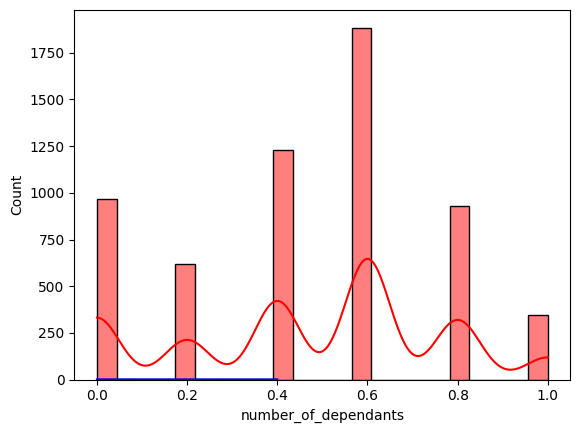

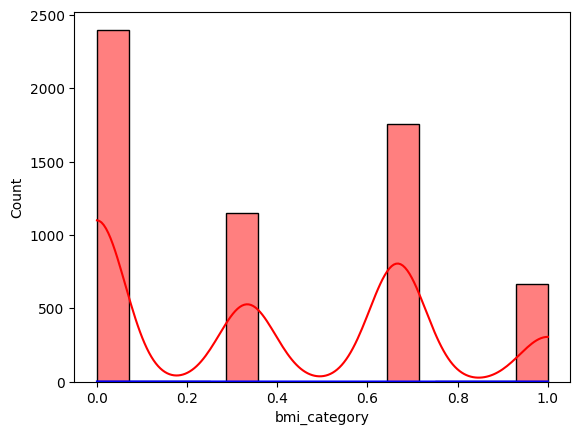

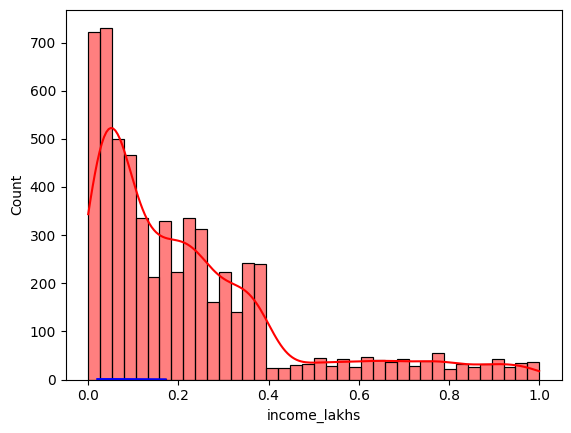

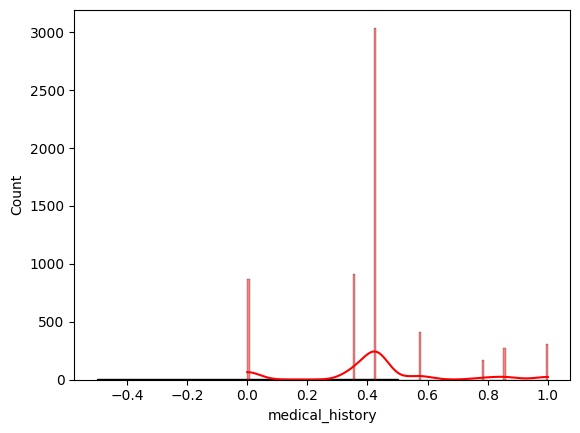

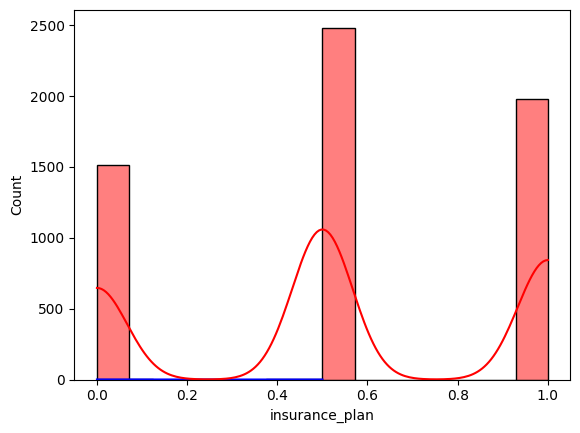

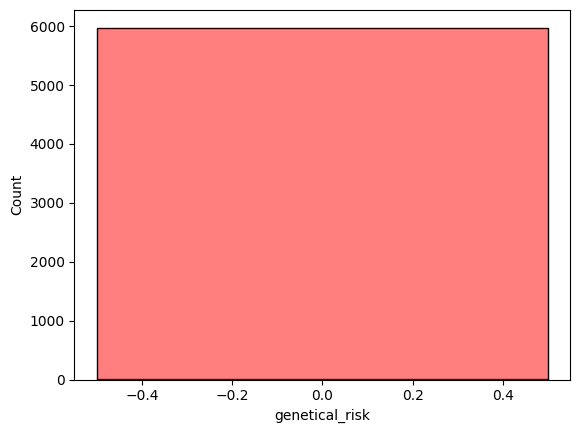

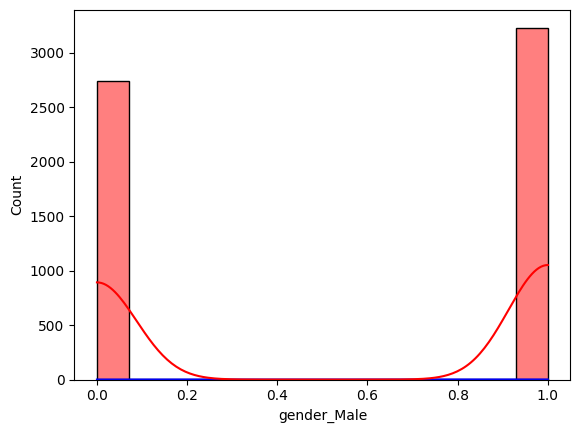

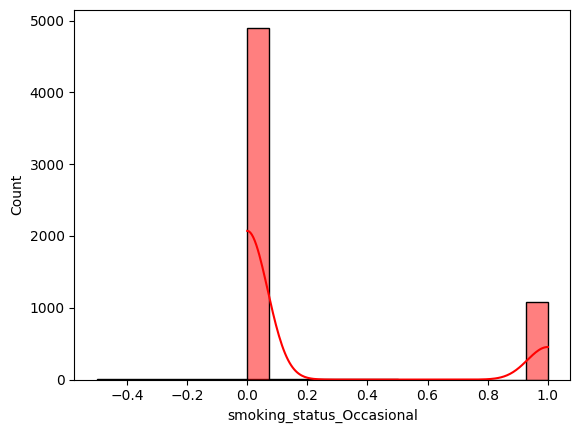

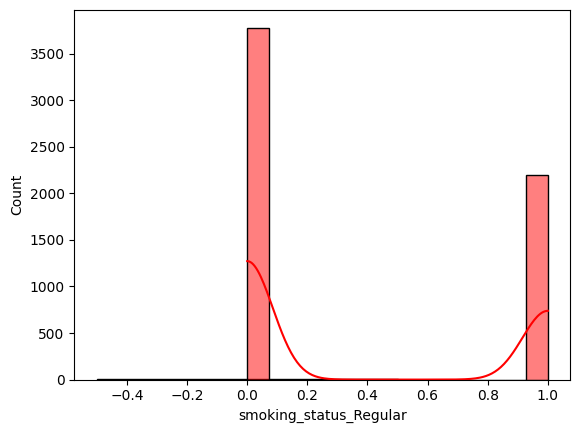

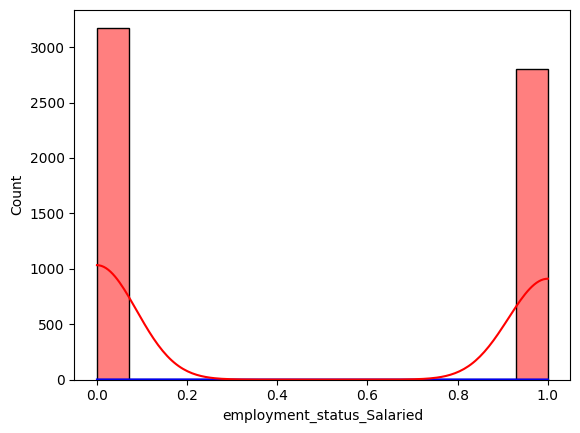

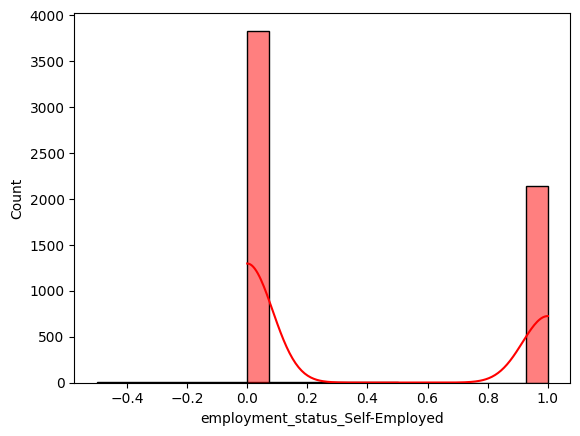

In [86]:
for features in x_test.columns:
    sns.histplot(extreme_error_df[features],color="Blue",kde=True)
    sns.histplot(x_test[features],color="red",kde=True)
    plt.show()

# reverse scaling
# segmentation

In [87]:
# I want to find the actual value of features (not the sacled value)
df_reversed=pd.DataFrame()
extreme_error_df['income_level']=-1
extreme_error_df['marital_status_Unmarried']=-1
df_reversed[cols_to_scale]=scaler.inverse_transform(extreme_error_df[cols_to_scale])
df_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,42.0,2.0,1.0,0.0,-3.0,8.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0
1,42.0,3.0,2.0,3.0,-3.0,4.0,0.0,1.0,1.0,-1.0,0.0,0.0,0.0,0.0
2,42.0,1.0,0.0,0.0,-3.0,3.0,0.0,0.0,0.0,-1.0,0.0,0.0,1.0,0.0
3,42.0,2.0,0.0,0.0,-3.0,18.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0


In [88]:
# reverse_scaling for actual test data
x_test_copy=x_test.copy()
df_test_reversed=pd.DataFrame()
x_test_copy['income_level']=-1
x_test_copy['marital_status_Unmarried']=-1
df_test_reversed[cols_to_scale]=scaler.inverse_transform(x_test_copy[cols_to_scale])
df_test_reversed

,age,region,number_of_dependants,bmi_category,income_level,income_lakhs,medical_history,insurance_plan,gender_Male,marital_status_Unmarried,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,55.0,2.0,2.0,0.0,-3.0,3.0,6.0,2.0,0.0,-1.0,0.0,0.0,0.0,1.0
1,56.0,2.0,1.0,2.0,-3.0,12.0,5.0,0.0,1.0,-1.0,0.0,1.0,1.0,0.0
2,52.0,1.0,2.0,0.0,-3.0,8.0,5.0,0.0,0.0,-1.0,1.0,0.0,1.0,0.0
3,39.0,2.0,4.0,1.0,-3.0,25.0,6.0,1.0,1.0,-1.0,0.0,0.0,1.0,0.0
4,52.0,3.0,3.0,2.0,-3.0,13.0,5.0,2.0,1.0,-1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5971,66.0,3.0,1.0,3.0,-3.0,85.0,6.0,1.0,1.0,-1.0,0.0,0.0,0.0,1.0
5972,31.0,3.0,3.0,0.0,-3.0,35.0,0.0,1.0,1.0,-1.0,0.0,0.0,0.0,1.0
5973,42.0,2.0,0.0,0.0,-3.0,32.0,6.0,2.0,1.0,-1.0,1.0,0.0,0.0,0.0
5974,42.0,2.0,0.0,0.0,-3.0,18.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0


In [89]:
x_test.columns

Index(['age', 'region', 'number_of_dependants', 'bmi_category', 'income_lakhs',
       'medical_history', 'insurance_plan', 'genetical_risk', 'gender_Male',
       'smoking_status_Occasional', 'smoking_status_Regular',
       'employment_status_Salaried', 'employment_status_Self-Employed'],
      dtype='object')

<Axes: xlabel='age', ylabel='Count'>

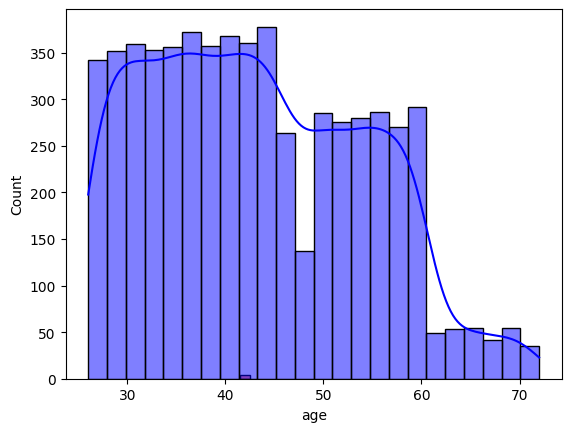

In [90]:
sns.histplot(df_reversed['age'],color='red',kde=True)
sns.histplot(df_test_reversed.age,color='blue',kde=True)

In [91]:
print((df_reversed.age<25).count())

4


In [92]:
# people below the age of 25 are unpredictable

# solution 1:Delete the entries below the age 25
# solution 2: segmentation 
# segmentation:
- segmentation is the process of dividing a large dataset or population into smaller groups that share similar characteristics to enable better analysis or decision-making.

In [93]:
df_young=df[df.age<=25]
df_rest=df[df.age>25]

# Exporting the trained model and scaler object uisng joblib

In [94]:
best_model=random_search.best_estimator_
print(best_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.5, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=30,
             n_jobs=None, num_parallel_tree=None, ...)


In [95]:
from joblib import dump


In [96]:
dump(best_model,"artifacts/model_rest.joblib")
#To scale the user input before giving to trained model
scaler_with_cols={
              'scaler':scaler,
              'cols_to_scale':cols_to_scale
}
dump(scaler_with_cols,"artifacts/scaler_rest.joblib")

['artifacts/scaler_rest.joblib']